### Project Summary
In this project, I analyzed U.S. construction materials sales data (2019–2024) using exploratory data analysis (EDA), descriptive statistics, and time series analysis to uncover revenue growth trends, seasonal demand patterns, product-category-level price distributions, regional variations, customer segment trends, and sales channel performance. Additionally, I examined the relationship between construction material demand and macroeconomic indicators, including the Housing Starts Index, to explore how housing market activity relates to material demand.

**Data Source**: Kaggle <br>
**Currency**: All monetory values are presented in USD

### What I Did
- Cleaned and prepared transaction-level data using Pandas and NumPy, including date handling, missing-value checks and data validation.
- Performed exploratory data analysis across revenue, units, unit prices, product categories, regions, channels and customer types.
- Analyzed monthly and yearly sales trends to identify seasonality and changes in revenue performance.
- Examined the relationship between construction material demand and macroeconomic indicators to explore how housing market activity relates to material demand.
- Compared product categories and SKUs based on revenue, sales volume and price distributions.
- Examined regional, customer-type and channel-level sales performance.
- Developed visualizations using Matplotlib and Seaborn to communicate trends, distributions, comparisons and relationships.

### Outcome
The analysis provided a structured view of construction-material sales performance and highlighted seasonal demand patterns, product and pricing differences, regional variations, customer/channel behavior, and relationships between materials demand and broader construction-market indicators.

In [2]:
#Imported libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

In [3]:
#Set the visual styles
plt.style.use('Solarize_Light2')

In [4]:
# Created a reusable function to format Y axis in millions
def format_millions(ax):
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda x, _: f'{x/1_000_000:.0f}M')
    )

In [5]:
#loaded the csv file 
df_sales = pd.read_csv(r'C:\Users\Nafre\Desktop\Projects\Building Material Data\building_materials_transactions.csv')

In [6]:
#Display the 1st 3 rows
df_sales.head(3)

,Date,Year,Month,Week of the Year,Region,Product Category,SKU,Channel,Customer Type,Units,Unit Price,Revenue,Housing Starts Index,Lumber Price Index,Mortgage Rate
0,1/7/2019,2019,1,2,East_North_Central,Roofing,ROO-1877,Pro Dealer,Remodeler,3,85.01,255.03,96.4,388,3.95
1,1/7/2019,2019,1,2,Middle_Atlantic,Lumber,LUM-2991,Pro Dealer,Contractor,75,5.80,435.00,96.4,388,3.95
2,1/7/2019,2019,1,2,Pacific,Concrete Cement,CON-9954,Big Box DIY,Contractor,98,7.48,733.04,96.4,388,3.95


In [7]:
#Summary statistics
df_sales.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,340000.0,2021.543909,1.711975,2019.00,2020.00,2022.00,2023.00,2024.00
Month,340000.0,6.614615,2.991934,1.00,4.00,7.00,9.00,12.00
Week of the Year,340000.0,27.140406,13.079173,1.00,17.00,27.00,37.00,53.00
Units,340000.0,140.998726,233.354218,1.00,13.00,45.00,168.00,4301.00
Unit Price,340000.0,51.284760,88.881355,5.43,8.35,14.05,42.24,503.91
Revenue,340000.0,1737.228427,2068.541393,5.80,438.30,1037.40,2242.50,49596.74
Housing Starts Index,340000.0,107.818749,7.977620,92.70,100.80,107.30,114.60,127.70
Lumber Price Index,340000.0,497.285941,252.125178,333.00,392.00,408.00,430.00,1548.00
Mortgage Rate,340000.0,5.518189,1.742805,2.84,3.88,5.52,7.42,7.63


In [8]:
#Dataset information
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340000 entries, 0 to 339999
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Date                  340000 non-null  object 
 1   Year                  340000 non-null  int64  
 2   Month                 340000 non-null  int64  
 3   Week of the Year      340000 non-null  int64  
 4   Region                340000 non-null  object 
 5   Product Category      340000 non-null  object 
 6   SKU                   340000 non-null  object 
 7   Channel               340000 non-null  object 
 8   Customer Type         340000 non-null  object 
 9   Units                 340000 non-null  int64  
 10  Unit Price            340000 non-null  float64
 11  Revenue               340000 non-null  float64
 12  Housing Starts Index  340000 non-null  float64
 13  Lumber Price Index    340000 non-null  int64  
 14  Mortgage Rate         340000 non-null  float64
dtype

In [9]:
#Checked for missing values
df_sales.isnull().sum()

Date                    0
Year                    0
Month                   0
Week of the Year        0
Region                  0
Product Category        0
SKU                     0
Channel                 0
Customer Type           0
Units                   0
Unit Price              0
Revenue                 0
Housing Starts Index    0
Lumber Price Index      0
Mortgage Rate           0
dtype: int64

In [10]:
#Checked for duplicated records
df_sales.duplicated().sum()

np.int64(0)

In [11]:
#Standardized column names
df_sales.columns = (df_sales.columns
                        .str.strip()
                        .str.lower()
                        .str.replace(' ', '_')
                   )          

In [12]:
#Converted date column to datetime format
df_sales['date'] = pd.to_datetime(df_sales['date'])

In [13]:
#Extracted abbreviated month names from date column
df_sales['month_name'] = df_sales['date'].dt.month_name().str[0:3]

In [14]:
#Extracted quarter from the date column
df_sales['quarter_num'] = df_sales['date'].dt.quarter

In [15]:
#Displayed 2 rows of dataframe after transformation
df_sales.head(2)

,date,year,month,week_of_the_year,region,product_category,sku,channel,customer_type,units,unit_price,revenue,housing_starts_index,lumber_price_index,mortgage_rate,month_name,quarter_num
0,2019-01-07,2019,1,2,East_North_Central,Roofing,ROO-1877,Pro Dealer,Remodeler,3,85.01,255.03,96.4,388,3.95,Jan,1
1,2019-01-07,2019,1,2,Middle_Atlantic,Lumber,LUM-2991,Pro Dealer,Contractor,75,5.80,435.00,96.4,388,3.95,Jan,1


In [16]:
#Calculated the minimum and maximum unit price for each product category
df_sales.groupby('product_category')['unit_price'].agg(['min', 'max']).reset_index()

,product_category,min,max
0,Concrete Cement,7.18,11.77
1,Drywall,10.71,20.11
2,Electrical,19.79,30.14
3,Hardware Fasteners,8.05,14.13
4,Insulation,39.97,79.72
5,Lumber,5.43,20.73
6,Paint Coatings,31.52,44.47
7,Plumbing,25.21,38.39
8,Roofing,83.87,178.07
9,Windows Doors,286.28,503.91


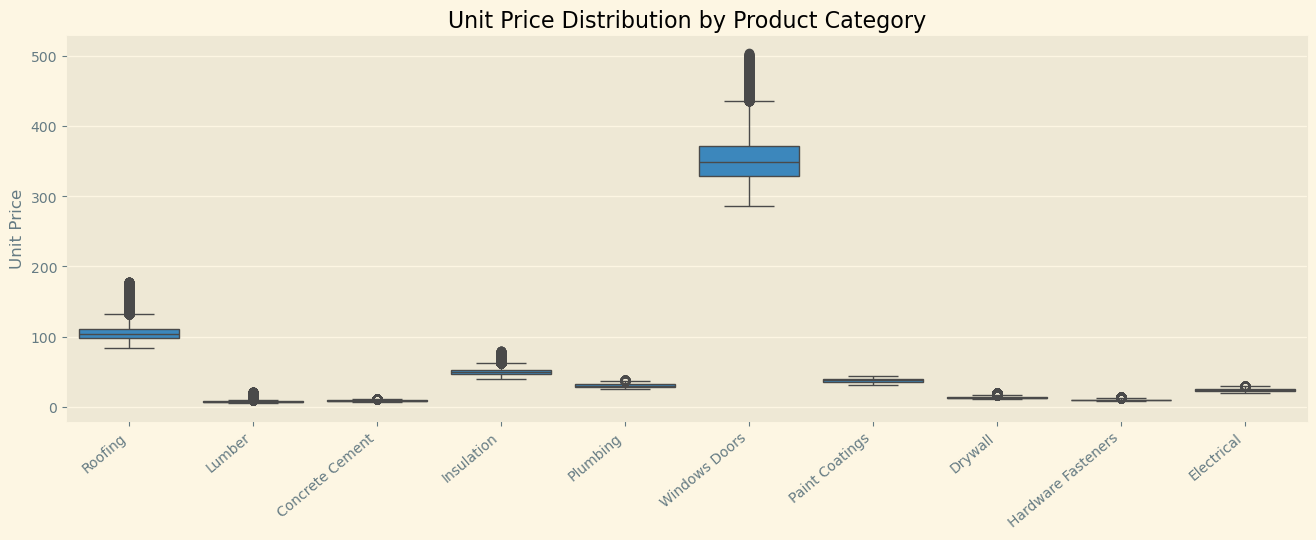

In [29]:
#Visualized and compared price distribution by product category

plt.figure(figsize=(16, 5))
sns.boxplot(data=df_sales, x='product_category', y='unit_price')
plt.title('Unit Price Distribution by Product Category')
plt.ylabel('Unit Price')
plt.xlabel('')
plt.xticks(rotation=40, ha='right')
plt.show()

### Key Insights
- Windows & Doors have the highest unit prices compared with other product categories, with a median of around **\$350** and few outliers reaching **\$500**.
- Roofing prices are stable but show premium spikes: While standard roofing items cluster consistently near **\$100**, a distinct subset of specialty products drives maximum prices up toward **\$180**.
- The vast majority of standard categories including Lumber, Drywall, and Electrical maintain highly stable commodity pricing well under **\$50** with minimal market variance.

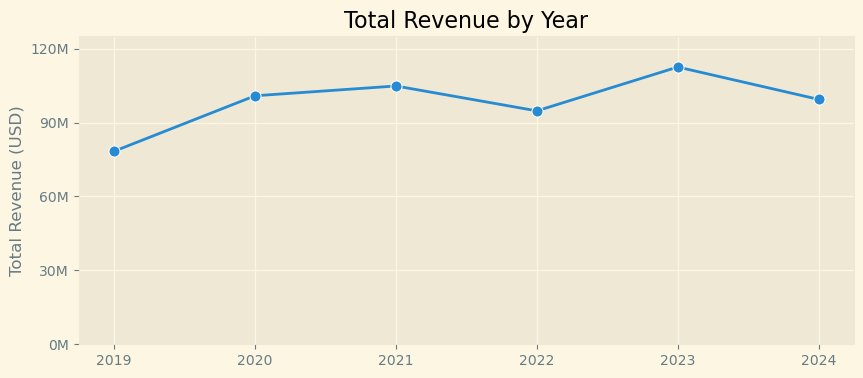

In [18]:
#Visualized the yearly sales trend

plt.figure(figsize=(10,4))
sns.lineplot(data=df_sales, 
             x='year', 
             y='revenue', 
             estimator='sum', 
             errorbar=None,
            marker='o',
            markersize=8)
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('')
plt.ylabel('Total Revenue (USD)')
plt.yticks([0, 30_000_000, 60_000_000, 90_000_000, 120_000_000])
plt.ylim(0, 125000000)
plt.title('Total Revenue by Year')
format_millions(plt.gca())
plt.show()

### Key Insights
- Annual revenue demonstrates robust long-term stability by consistently holding near or above the **\$100M** mark, navigating a minor performance dip in 2022 and a record peak in 2023 through normal year-over-year fluctuations.

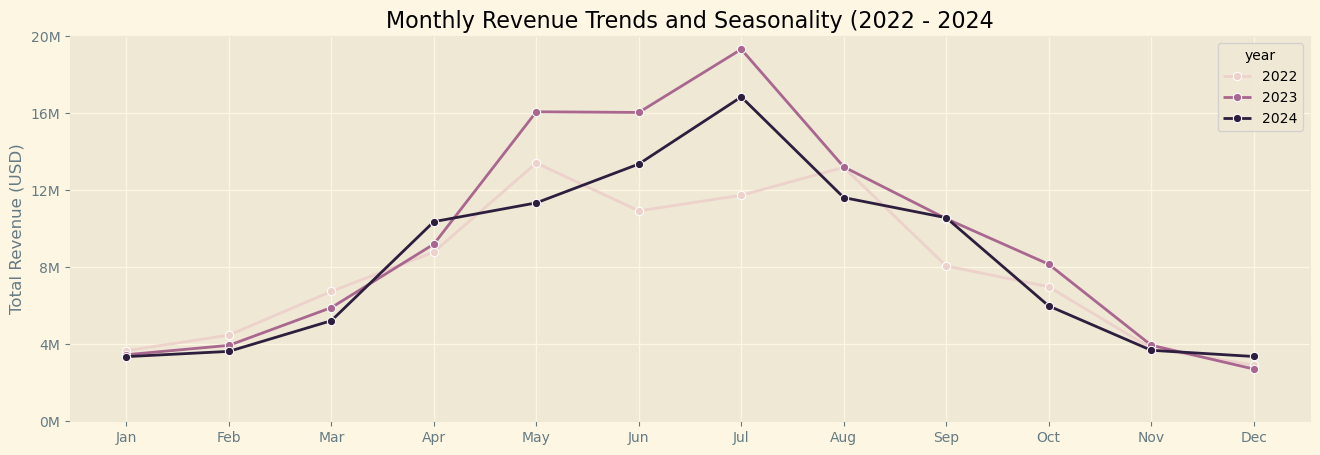

In [19]:
#Visualized revenue by seasonality trends
plt.figure(figsize=(16,5))
sns.lineplot(data=df_sales.query('year in [2022, 2023, 2024]'),
             x='month_name',
             y='revenue',
             hue='year',
             estimator='sum',
             marker='o',
             errorbar=None
            )
plt.xlabel('')
plt.ylabel('Total Revenue (USD)')
plt.yticks([0, 4_000_000, 8_000_000, 12_000_000, 16_000_000, 20_000_000])
plt.ylim(0, 20000000)
plt.title('Monthly Revenue Trends and Seasonality (2022 - 2024')
format_millions(plt.gca())
plt.show()

### Insights
- Monthly revenue follows a highly predictable seasonal pattern across all years, with lows below **\$4M** in January, February, November, and December, and strong mid-year peaks, particularly in July. Revenue reached a record high of nearly **\$20M** in 2023, while 2024 peaked at around **\$17M**. In 2022, revenue showed a unique double-peak pattern in May and July.

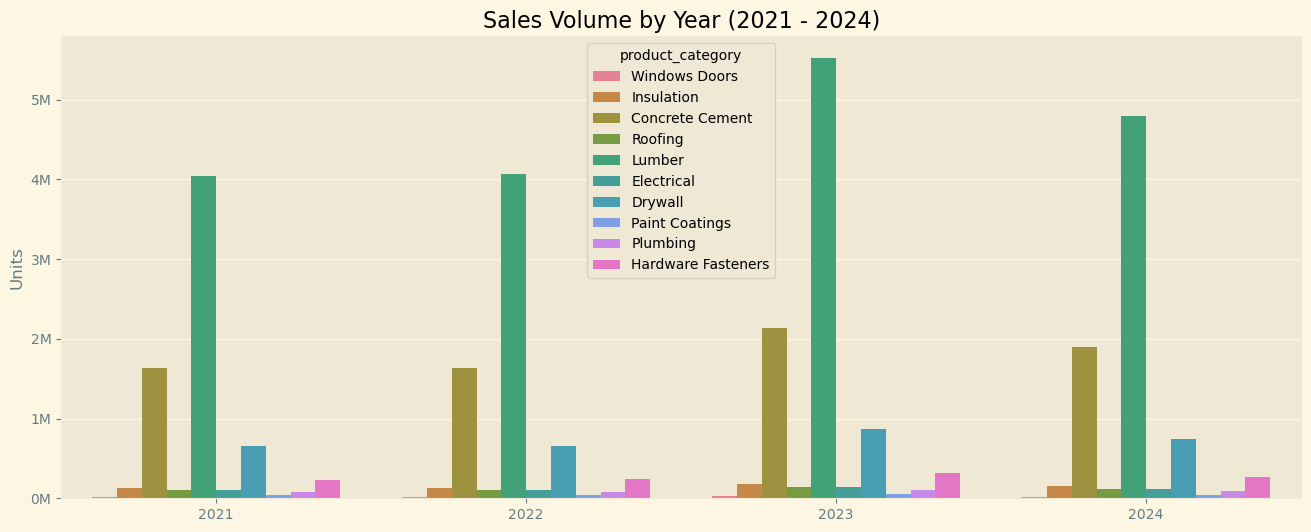

In [20]:
#Visualized revenue by year and customer type

plt.figure(figsize=(16, 6))
sns.barplot(data=df_sales.query('year in [2021, 2022, 2023, 2024]'), 
            x='year', 
            y='units', 
            estimator='sum', 
            hue='product_category',
            errorbar= None
           )
plt.xlabel('')
plt.ylabel('Units')
plt.title('Sales Volume by Year (2021 - 2024)')
format_millions(plt.gca())
plt.show()

### Key Insights
- Lumber acts as the primary volume and revenue anchor for the portfolio, peaking at ~5.5 million units in 2023 before declining to ~4.8 million units in 2024. Its significant contribution to overall sales means that changes in lumber demand or pricing can have a substantial impact on the company’s overall revenue performance, highlighting the importance of monitoring this category closely.
- Concrete Cement serves as the second-largest volume driver, peaking at ~2.1 million units in 2023 before softening to ~1.9 million units in 2024.

In [21]:

df_analysis = (df_sales.groupby(['date', 'product_category'])
                .agg({'units':'sum', 'housing_starts_index':'first'})
              ).reset_index()  

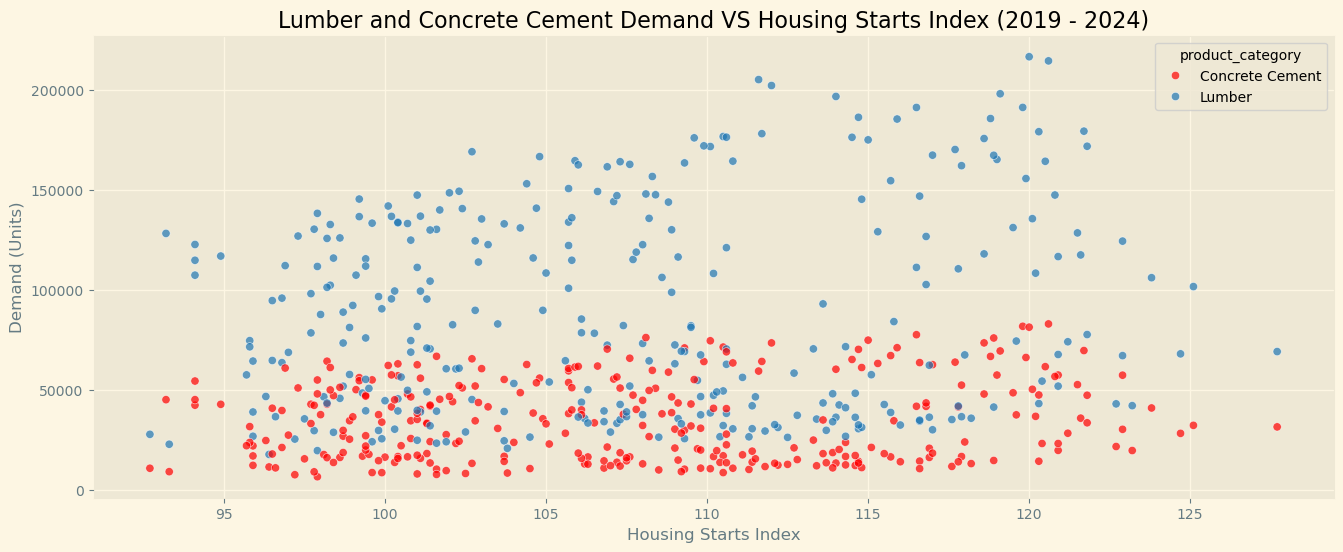

In [22]:
plt.figure(figsize=(16,6))
custom_palette = {
    'Lumber': '#1f77b4',         
    'Concrete Cement': '#ff0000'
}
sns.scatterplot(data=df_analysis.query('product_category in ["Lumber", "Concrete Cement"]'), 
            x='housing_starts_index', 
            y='units',
            hue='product_category',
            palette=custom_palette,
            alpha=0.7
          )
           
plt.xlabel('Housing Starts Index')
plt.ylabel('Demand (Units)')
plt.title('Lumber and Concrete Cement Demand VS Housing Starts Index (2019 - 2024)')
plt.show()

### Key Insights
- Both materials show a visible upward spread as the Housing Starts Index moves from 95 toward 120+, confirming that higher index values reliably translate to increased unit demands.
- Lumber demand becomes much more volatile and spread out at higher index levels (110–125), whereas Concrete Cement demand stays within a more tightly clustered, predictable band.
- Lumber consistently maintains a significantly higher volume of demand across all housing start levels compared to Concrete Cement.

In [23]:
df_revenue = (
            df_sales.query('year in [2022, 2023, 2024]')
            .groupby(['year', 'product_category'])['revenue']
            .sum()
            .reset_index()
)

df_yoy = (
            df_revenue
            .pivot_table(index='product_category', columns='year', values='revenue')
            .reset_index()
)

df_yoy.columns.name = None

df_yoy['2022_contribution_%'] = (
                df_yoy[2022] 
                / df_yoy[2022].sum() * 100
).round(2)

df_yoy['2023_contribution_%'] = (
                df_yoy[2023] 
                / df_yoy[2023].sum() * 100
).round(2)

df_yoy['2024_contribution_%'] = (
                df_yoy[2024] 
                / df_yoy[2024].sum() * 100
).round(2)

df_yoy.iloc[:, [0, 4, 5, 6]]

,product_category,2022_contribution_%,2023_contribution_%,2024_contribution_%
0,Concrete Cement,15.61,16.74,17.08
1,Drywall,9.72,10.16,10.13
2,Electrical,2.61,2.98,3.02
3,Hardware Fasteners,2.57,2.79,2.70
4,Insulation,7.36,7.76,7.72
5,Lumber,38.99,35.13,35.19
6,Paint Coatings,1.45,1.66,1.66
7,Plumbing,2.45,2.78,2.71
8,Roofing,12.62,12.84,12.77
9,Windows Doors,6.62,7.14,7.00


### Key Insights
- Lumber remained the largest contributor to overall revenue, but its share declined from 38.99% in 2022 to 35.13% in 2023, before stabilizing at 35.19% in 2024, indicating a gradual diversification of revenue across other categories.
- Concrete Cement increased its revenue share from 15.61% in 2022 to 17.08% in 2024, while Roofing remained the third-largest category with a stable 12.62%–12.77% share, indicating consistent revenue contribution.

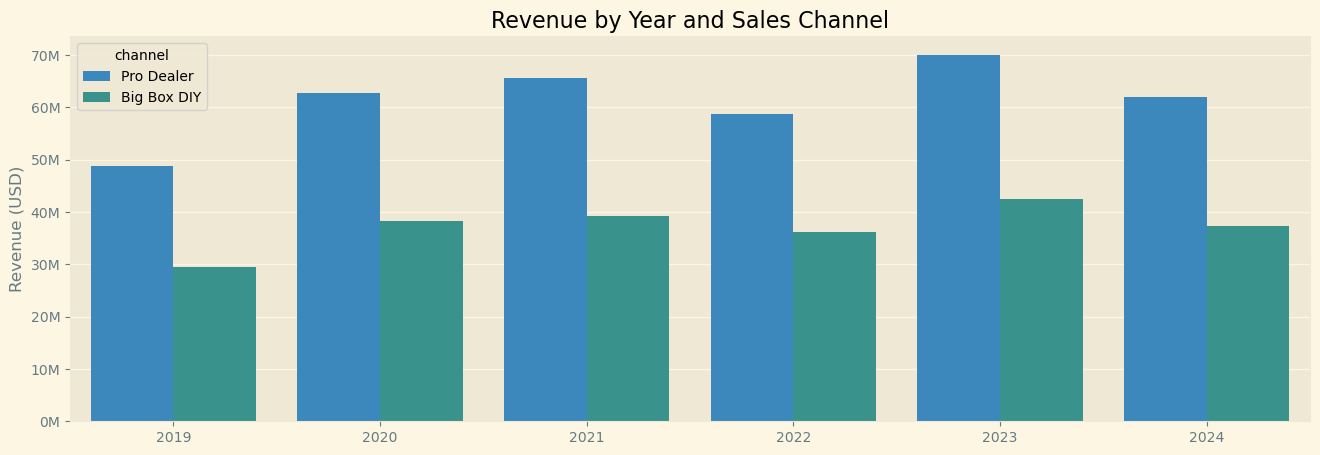

In [24]:
#Visualized revenue by year and sales channel

plt.figure(figsize=(16, 5))
sns.barplot(data=df_sales, 
            x='year', 
            y='revenue', 
            estimator='sum', 
            hue='channel',
            errorbar= None
           )
plt.xlabel('')
plt.ylabel('Revenue (USD)')
plt.title('Revenue by Year and Sales Channel')
format_millions(plt.gca())
plt.show()

### Key Insights
- Pro Dealer consistently serves as the primary revenue channel across all years, maintaining a clear performance gap over Big Box DIY. Both channels follow a similar trend, with growth in 2020, a slight decline in 2022, and a peak in 2023, when Pro Dealer reached **\$70M** and Big Box DIY exceeded **\$40M**.

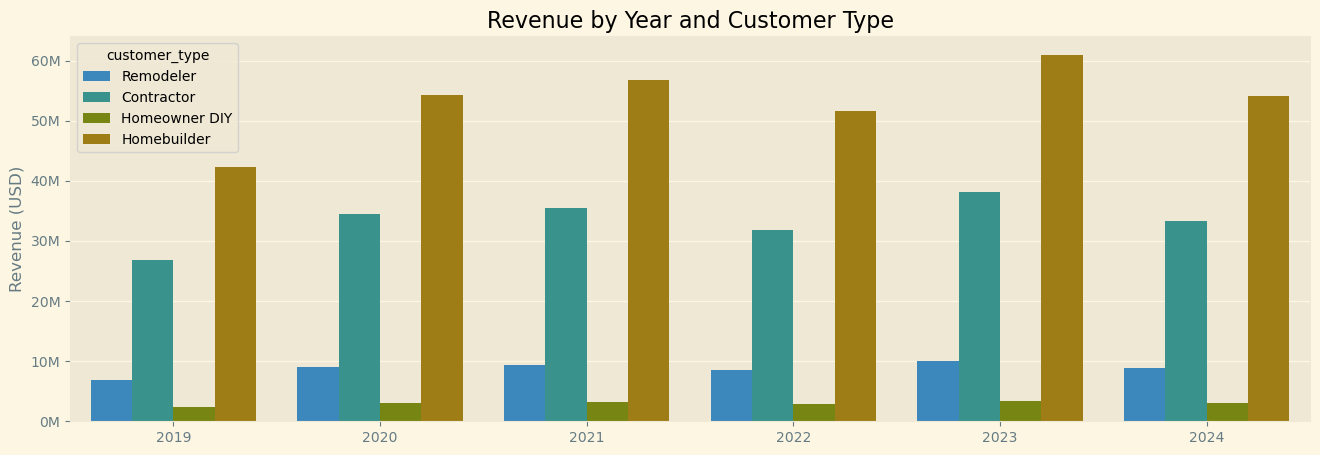

In [25]:
#Visualized revenue by year and customer type

plt.figure(figsize=(16, 5))
sns.barplot(data=df_sales, 
            x='year', 
            y='revenue', 
            estimator='sum', 
            hue='customer_type',
            errorbar= None
           )
plt.xlabel('')
plt.ylabel('Revenue (USD)')
plt.title('Revenue by Year and Customer Type')
format_millions(plt.gca())
plt.show()

### Key Insights
- Homebuilders and Contractors consistently generate the vast majority of annual revenue, making them the two largest customer segments across all years.
- All four segments follow a similar trend, with steady growth through 2021, a slight contraction in 2022, and a peak in 2023, when Homebuilders surpassed **\$60M** and Contractors reached nearly **\$38M**, before moderating slightly in 2024.

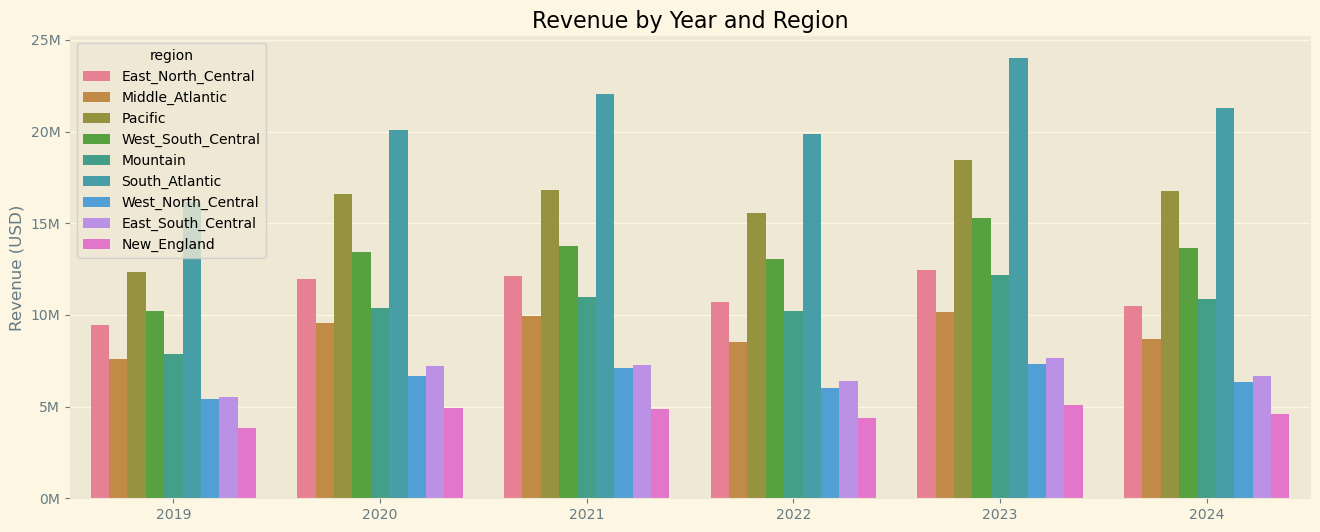

In [27]:
#Visualized revenue by year and customer type

plt.figure(figsize=(16, 6))
sns.barplot(data=df_sales, 
            x='year', 
            y='revenue', 
            estimator='sum', 
            hue='region',
            errorbar= None
           )
plt.xlabel('')
plt.ylabel('Revenue (USD)')
plt.title('Revenue by Year and Region')
format_millions(plt.gca())
plt.show()

### Key Insights
- The South Atlantic region consistently generates the highest revenue every year, peaking significantly at nearly **\$24M** in 2023 before slightly cooling in 2024.
- The Pacific region consistently holds the second-highest revenue position across all years. Conversely, New England continuously brings in the lowest revenue, remaining strictly below the **\$5M** mark.